# 01 — Exploração dos Dados
## Pipeline ETL End-to-End — Olist E-commerce Dataset

Neste notebook exploramos as 9 tabelas do dataset Olist para entender
a estrutura, qualidade e relacionamentos dos dados antes de construir o pipeline.

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Fonte:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
**Período:** 2016 a 2018

In [3]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"✅ Dataset carregado em: {path}")
print(f"\n📁 Arquivos disponíveis:")
for f in sorted(os.listdir(path)):
    size = os.path.getsize(os.path.join(path, f)) / 1024
    print(f"   {f:<50} {size:>8.1f} KB")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
✅ Dataset carregado em: /kaggle/input/brazilian-ecommerce

📁 Arquivos disponíveis:
   olist_customers_dataset.csv                          8822.2 KB
   olist_geolocation_dataset.csv                       59837.8 KB
   olist_order_items_dataset.csv                       15076.8 KB
   olist_order_payments_dataset.csv                     5641.7 KB
   olist_order_reviews_dataset.csv                     14113.0 KB
   olist_orders_dataset.csv                            17241.1 KB
   olist_products_dataset.csv                           2323.7 KB
   olist_sellers_dataset.csv                             170.6 KB
   product_category_name_translation.csv                   2.6 KB


In [4]:
customers          = pd.read_csv(f"{path}/olist_customers_dataset.csv")
sellers            = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
orders             = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items        = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
order_payments     = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
order_reviews      = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
products           = pd.read_csv(f"{path}/olist_products_dataset.csv")
geolocation        = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

tables = {
    'customers': customers, 'sellers': sellers,
    'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'products': products, 'geolocation': geolocation,
    'category_translation': category_translation
}

print("✅ Tabelas carregadas!\n")
print(f"{'Tabela':<25} {'Linhas':>10} {'Colunas':>10}")
print("-" * 47)
for name, df in tables.items():
    print(f"{name:<25} {len(df):>10,} {len(df.columns):>10}")

✅ Tabelas carregadas!

Tabela                        Linhas    Colunas
-----------------------------------------------
customers                     99,441          5
sellers                        3,095          4
orders                        99,441          8
order_items                  112,650          7
order_payments               103,886          5
order_reviews                 99,224          7
products                      32,951          9
geolocation                1,000,163          5
category_translation              71          2


In [5]:
print("=" * 60)
print("ANÁLISE DE VALORES NULOS POR TABELA")
print("=" * 60)

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(2)
    has_nulls = nulls[nulls > 0]
    if len(has_nulls) > 0:
        print(f"\n📋 {name.upper()}")
        for col in has_nulls.index:
            print(f"   {col:<45} {nulls[col]:>6} nulos ({nulls_pct[col]:.1f}%)")
    else:
        print(f"\n✅ {name.upper()} — sem valores nulos")

ANÁLISE DE VALORES NULOS POR TABELA

✅ CUSTOMERS — sem valores nulos

✅ SELLERS — sem valores nulos

📋 ORDERS
   order_approved_at                                160 nulos (0.2%)
   order_delivered_carrier_date                    1783 nulos (1.8%)
   order_delivered_customer_date                   2965 nulos (3.0%)

✅ ORDER_ITEMS — sem valores nulos

✅ ORDER_PAYMENTS — sem valores nulos

📋 ORDER_REVIEWS
   review_comment_title                           87656 nulos (88.3%)
   review_comment_message                         58247 nulos (58.7%)

📋 PRODUCTS
   product_category_name                            610 nulos (1.9%)
   product_name_lenght                              610 nulos (1.9%)
   product_description_lenght                       610 nulos (1.9%)
   product_photos_qty                               610 nulos (1.9%)
   product_weight_g                                   2 nulos (0.0%)
   product_length_cm                                  2 nulos (0.0%)
   product_height_cm       

📊 STATUS DOS PEDIDOS
   delivered                 96,478 (97.0%)
   shipped                    1,107 (1.1%)
   canceled                     625 (0.6%)
   unavailable                  609 (0.6%)
   invoiced                     314 (0.3%)
   processing                   301 (0.3%)
   created                        5 (0.0%)
   approved                       2 (0.0%)

📅 Primeiro pedido: 2016-09-04
   Último pedido:   2018-10-17
   Total:           99,441


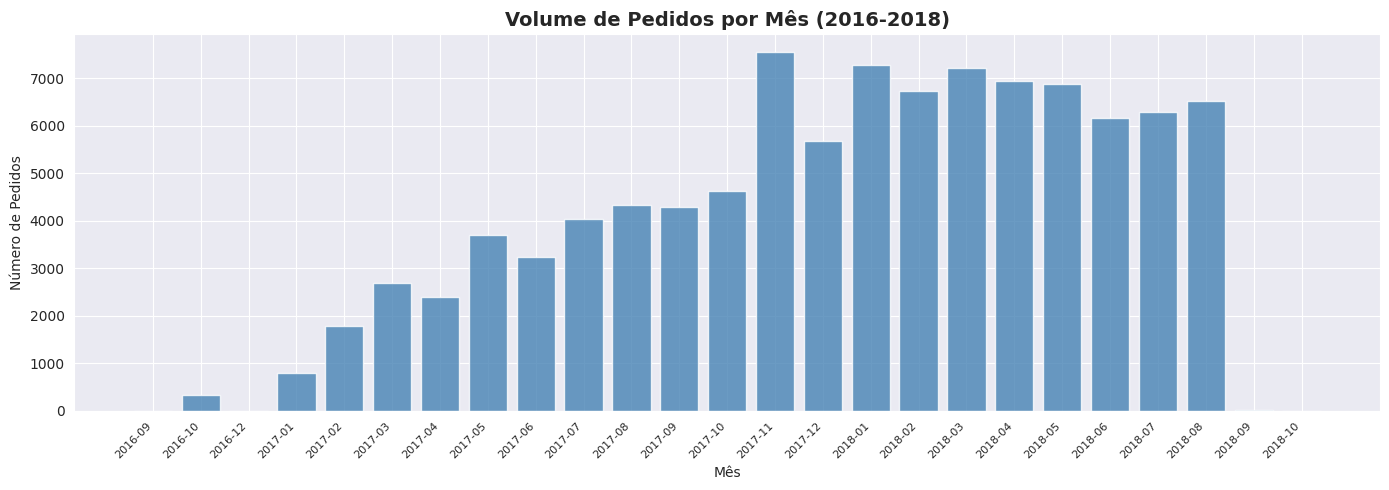

In [6]:
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("📊 STATUS DOS PEDIDOS")
status_counts = orders['order_status'].value_counts()
for status, count in status_counts.items():
    pct = count/len(orders)*100
    print(f"   {status:<25} {count:>6,} ({pct:.1f}%)")

print(f"\n📅 Primeiro pedido: {orders['order_purchase_timestamp'].min().date()}")
print(f"   Último pedido:   {orders['order_purchase_timestamp'].max().date()}")
print(f"   Total:           {len(orders):,}")

orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size().reset_index(name='pedidos')
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly['month_str'], monthly['pedidos'], color='steelblue', alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Volume de Pedidos por Mês (2016-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Número de Pedidos')
plt.tight_layout()
plt.show()

💳 FORMAS DE PAGAMENTO
   credit_card                76,795 (73.9%)
   boleto                     19,784 (19.0%)
   voucher                     5,775 (5.6%)
   debit_card                  1,529 (1.5%)
   not_defined                     3 (0.0%)

💰 TOTAL TRANSACIONADO: R$ 16,008,872.12


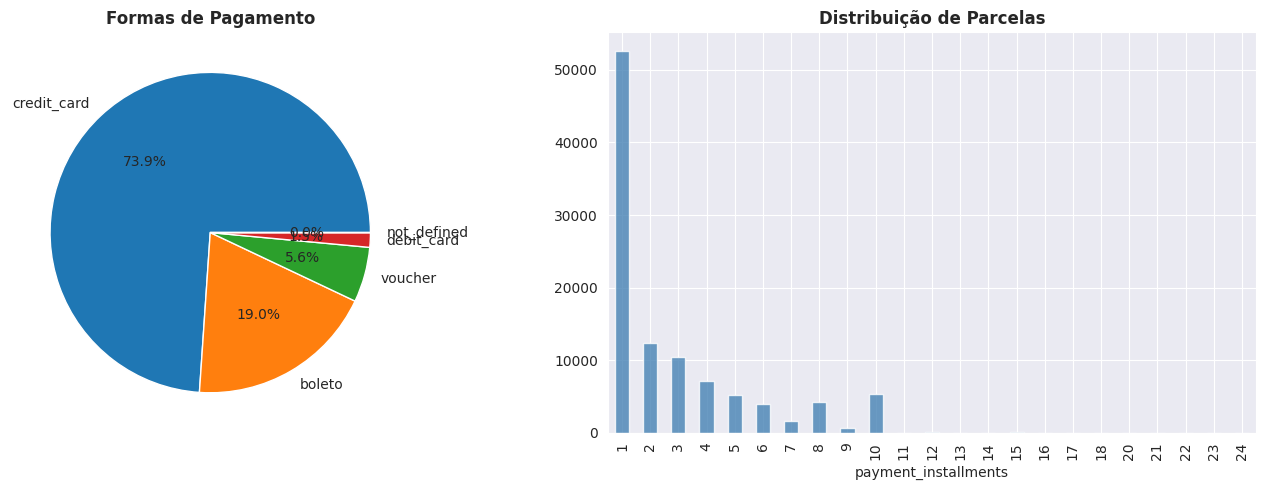

In [7]:
print("💳 FORMAS DE PAGAMENTO")
payment_counts = order_payments['payment_type'].value_counts()
for ptype, count in payment_counts.items():
    pct = count/len(order_payments)*100
    print(f"   {ptype:<25} {count:>7,} ({pct:.1f}%)")

print(f"\n💰 TOTAL TRANSACIONADO: R$ {order_payments['payment_value'].sum():,.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
ax1.set_title('Formas de Pagamento', fontweight='bold')
order_payments[order_payments['payment_installments']>0]['payment_installments']\
    .value_counts().sort_index().plot(kind='bar', ax=ax2, color='steelblue', alpha=0.8)
ax2.set_title('Distribuição de Parcelas', fontweight='bold')
plt.tight_layout()
plt.show()

⭐ AVALIAÇÕES
   ★☆☆☆☆  11,424 (11.5%)
   ★★☆☆☆   3,151 (3.2%)
   ★★★☆☆   8,179 (8.2%)
   ★★★★☆  19,142 (19.3%)
   ★★★★★  57,328 (57.8%)

   Nota média: 4.09 / 5.00


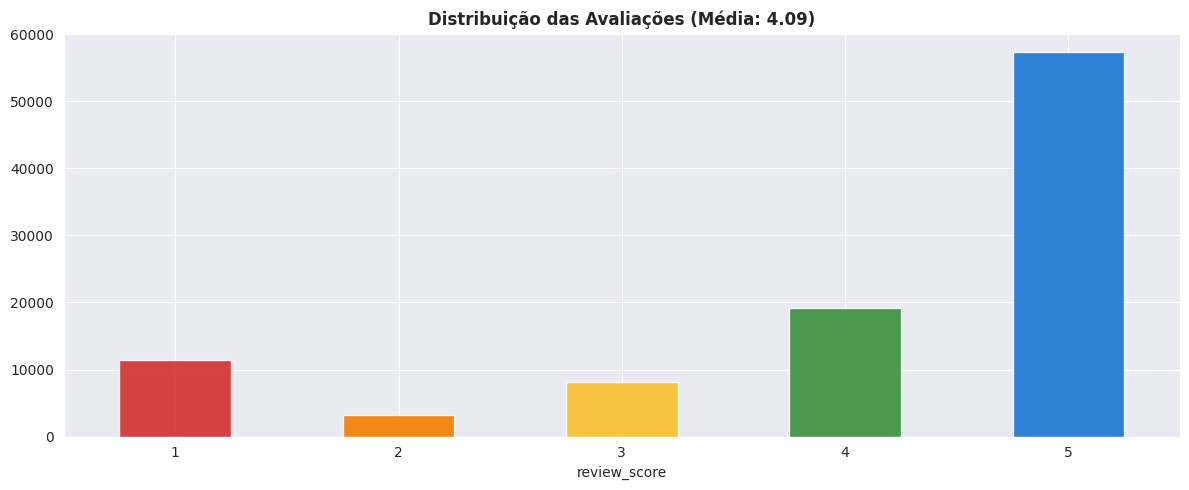

In [8]:
print("⭐ AVALIAÇÕES")
review_counts = order_reviews['review_score'].value_counts().sort_index()
for score, count in review_counts.items():
    stars = '★' * int(score) + '☆' * (5-int(score))
    pct = count/len(order_reviews)*100
    print(f"   {stars}  {count:>6,} ({pct:.1f}%)")

avg = order_reviews['review_score'].mean()
print(f"\n   Nota média: {avg:.2f} / 5.00")

review_counts.plot(kind='bar',
    color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'], alpha=0.9)
plt.title(f'Distribuição das Avaliações (Média: {avg:.2f})', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

📦 TOP 10 CATEGORIAS
   bed_bath_table                           11,115
   health_beauty                             9,670
   sports_leisure                            8,641
   furniture_decor                           8,334
   computers_accessories                     7,827
   housewares                                6,964
   watches_gifts                             5,991
   telephony                                 4,545
   garden_tools                              4,347
   auto                                      4,235


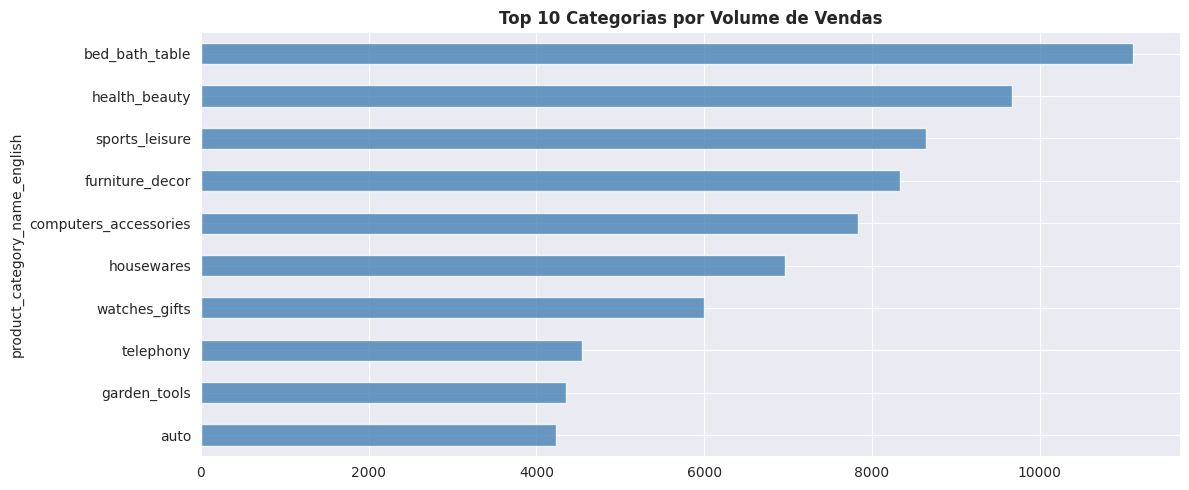

In [9]:
products_pt = products.merge(category_translation, on='product_category_name', how='left')

top_categories = (
    order_items
    .merge(products_pt[['product_id','product_category_name_english']], on='product_id')
    .groupby('product_category_name_english')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("📦 TOP 10 CATEGORIAS")
for cat, count in top_categories.items():
    print(f"   {str(cat):<40} {count:>6,}")

top_categories.sort_values().plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 10 Categorias por Volume de Vendas', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
total_revenue = order_items['price'].sum() + order_items['freight_value'].sum()
delivered = orders[orders['order_status'] == 'delivered']
avg_delivery = (delivered['order_delivered_customer_date'] -
                delivered['order_purchase_timestamp']).dt.days.mean()

print("=" * 60)
print("RESUMO EXECUTIVO — OLIST DATASET")
print("=" * 60)
print(f"""
📊 VOLUME
   Pedidos totais:          {len(orders):>10,}
   Itens vendidos:          {len(order_items):>10,}
   Clientes únicos:         {customers['customer_unique_id'].nunique():>10,}
   Vendedores ativos:       {len(sellers):>10,}

💰 FINANCEIRO
   Receita total:           R$ {total_revenue:>12,.2f}
   Ticket médio por item:   R$ {order_items['price'].mean():>12,.2f}
   Frete médio:             R$ {order_items['freight_value'].mean():>12,.2f}

⭐ QUALIDADE
   Nota média:              {order_reviews['review_score'].mean():>12.2f} / 5.00
   Taxa de entrega:         {len(delivered)/len(orders)*100:>11.1f}%
   Prazo médio de entrega:  {avg_delivery:>10.1f} dias
""")
print("PRÓXIMA ETAPA: 02_ingestion.ipynb")
print("=" * 60)

RESUMO EXECUTIVO — OLIST DATASET

📊 VOLUME
   Pedidos totais:              99,441
   Itens vendidos:             112,650
   Clientes únicos:             96,096
   Vendedores ativos:            3,095

💰 FINANCEIRO
   Receita total:           R$ 15,843,553.24
   Ticket médio por item:   R$       120.65
   Frete médio:             R$        19.99

⭐ QUALIDADE
   Nota média:                      4.09 / 5.00
   Taxa de entrega:                97.0%
   Prazo médio de entrega:        12.1 dias

PRÓXIMA ETAPA: 02_ingestion.ipynb
